## 查看历史检查点（状态)

In [3]:
from typing import TypedDict

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

# 获取模型
load_dotenv(override=True)
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str


# 1.1 输入状态
class InputState(TypedDict):
    topic: str


# 1.2 输出状态
class OutputState(TypedDict):
    final_output: str


# 3、定义节点
def node_poem(state: InputState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}的七言绝句")]).content
    return {
        "poem": poem
    }


def node_joke(state: InputState) -> OverAllState:
    logger.info("node_joke正在执行")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一个关于{topic}的笑话")]).content
    return {
        "joke": joke
    }


# 输出节点，处理处理状态
def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}的七言绝句：{poem}, \n笑话：{joke}\n"
    return {
        "final_output": final_output
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

builder.add_edge(START, "node_poem")
builder.add_edge(START, "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

# 4、添加检查点
checkpointer = InMemorySaver()
config = {
    "configurable": {
        "thread_id": "123"
    }
}

# 5、编译执行
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic": "莲花"}, config=config)
print(res)

2026-07-23 11:06:07.503 | INFO     | __main__:node_joke:52 - node_joke正在执行
2026-07-23 11:06:07.505 | INFO     | __main__:node_poem:43 - node_poem正在执行
2026-07-23 11:06:10.464 | INFO     | __main__:node_output:62 - node_output正在执行


{'final_output': '关于莲花的七言绝句：《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。, \n笑话：一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）\n'}


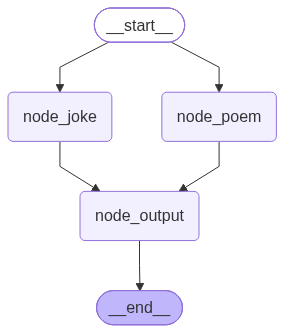

In [4]:
from IPython.display import display

display(graph)

In [5]:
# 根据 config 获取历史保存点
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'topic': '莲花', 'poem': '《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。', 'joke': '一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）', 'final_output': '关于莲花的七言绝句：《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。, \n笑话：一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-4bcb-6e13-8002-0a4b33fbdfe7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-23T03:06:10.465322+00:00', parent_config={'configurable': {'thr

[
StateSnapshot(values={'topic': '莲花', 'poem': '《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。', 'joke': '一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）', 'final_output': '关于莲花的七言绝句：《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。, \n笑话：一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-4bcb-6e13-8002-0a4b33fbdfe7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-23T03:06:10.465322+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-4bc8-6f28-8001-7cbb3322b212'}}, tasks=(), interrupts=()),

StateSnapshot(values={'topic': '莲花', 'poem': '《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。', 'joke': '一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）'}, next=('node_output',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-4bc8-6f28-8001-7cbb3322b212'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-23T03:06:10.464118+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-2f8b-657e-8000-b245f10a0e2e'}}, tasks=(PregelTask(id='9254d03f-87bc-9059-4cf6-2290ed2892d4', name='node_output', path=('__pregel_pull', 'node_output'), error=None, interrupts=(), state=None, result={'final_output': '关于莲花的七言绝句：《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。, \n笑话：一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）\n'}),), interrupts=()),

StateSnapshot(values={'topic': '莲花'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-2f8b-657e-8000-b245f10a0e2e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-23T03:06:07.502876+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-2f89-66d4-bfff-9469b2003139'}}, tasks=(PregelTask(id='ae80f178-7852-9a19-b223-095ee62cb2e4', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《莲花》\n玉立亭亭出碧塘，临风浥露自生香。\n不同百卉争春色，独向炎天吐艳芳。\n\n赏析：这首作品描绘莲花清雅高洁的形态与品格。首句“玉立亭亭”以拟人手法塑造其超然之姿，次句“浥露生香”强化清芬特质。后两句通过对比手法，以“不争春色”反衬莲花不趋炎附势的品格，用“独向炎天”彰显其迎难而上的风骨，完成了对莲之高洁精神的诗意升华。'}), PregelTask(id='79a7dc8a-44ae-7fa6-3cb5-11feaf78f06a', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, interrupts=(), state=None, result={'joke': '一个关于莲花的冷笑话：  \n\n**莲花和荷叶吵架了。**  \n荷叶嫌弃地说：“你整天‘出淤泥而不染’，装什么清高？我跟你一起长在泥里，怎么没人夸我？”  \n莲花淡定地回了一句：“因为你是个‘藕’像派。”  \n\n荷叶：“……”（气得绿了三天三夜。）  \n\n（冷到莲蓬都缩起来了🌚）'})), interrupts=()),

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f186437-2f89-66d4-bfff-9469b2003139'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-07-23T03:06:07.502094+00:00', parent_config=None, tasks=(PregelTask(id='d2545741-51cd-7178-f78b-e6c2e92ea103', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': '莲花'}),), interrupts=())

]